# Loan Approval -- Full ML Pipeline



## Phase 0 -- Environment Setup
Install packages, load secrets, verify MLflow and MongoDB.

In [1]:
# Install required packages
# pymongo : MongoDB client for raw data persistence
# mlflow  : experiment & model tracking
# dagshub : DagsHub <-> MLflow bridge
!pip install pymongo mlflow dagshub --quiet
print("Packages installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 53.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/20

In [3]:
import os
from google.colab import userdata

# MongoDB connection string -- stored as Colab Secret: MONGO_DB_URL
os.environ['MONGO_DB_URL'] = userdata.get('MONGO_DB_URL')

# MLflow / DagsHub -----------------------------------------------------------
USE_DAGSHUB = True  # updated -- set False to log locally inside Colab

if USE_DAGSHUB:
    os.environ['MLFLOW_TRACKING_URI']      = userdata.get('MLFLOW_TRACKING_URI')
    os.environ['MLFLOW_TRACKING_USERNAME'] = userdata.get('MLFLOW_TRACKING_USERNAME')
    os.environ['MLFLOW_TRACKING_PASSWORD'] = userdata.get('MLFLOW_TRACKING_PASSWORD')
else:
    # Local MLflow -- run artifacts saved inside Colab (no DagsHub needed)
    os.environ['MLFLOW_TRACKING_URI'] = f"file://{os.getcwd()}/mlruns"

print('Env vars set.')
print(f"   MLFLOW_TRACKING_URI = {os.environ['MLFLOW_TRACKING_URI']}")

Env vars set.
   MLFLOW_TRACKING_URI = https://dagshub.com/prithusarkar90/networksecurity.mlflow


In [4]:
import mlflow

mlflow.set_tracking_uri(os.environ['MLFLOW_TRACKING_URI'])
print('MLflow tracking URI:', mlflow.get_tracking_uri())
print('MLflow ready.')

MLflow tracking URI: https://dagshub.com/prithusarkar90/networksecurity.mlflow
MLflow ready.


In [5]:
from pymongo import MongoClient

mongo_client = MongoClient(os.environ['MONGO_DB_URL'])
print('MongoDB version:', mongo_client.server_info()['version'])
print('MongoDB connected.')

MongoDB version: 8.0.20
MongoDB connected.


## Phase 1 -- Data Ingestion
Upload CSV -> load into pandas -> push raw records to MongoDB.

In [6]:
# Upload the dataset from your local machine
# A file-picker dialog will appear in the browser
from google.colab import files
uploaded = files.upload()

Saving loan_approval_dataset.csv to loan_approval_dataset.csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

csv_filename = list(uploaded.keys())[0]
df = pd.read_csv(csv_filename)
df.columns = df.columns.str.strip()  # remove accidental whitespace

print(f'Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns')
display(df.head())

Dataset loaded: 4269 rows x 13 columns


,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [8]:
# Push raw data to MongoDB
# Database: loan_db  |  Collection: raw_applications
db         = mongo_client['loan_db']
collection = db['raw_applications']

# Replace NaN with None so records are JSON-serialisable
records = df.where(pd.notnull(df), None).to_dict(orient='records')

# Drop previous data to avoid duplicates on re-runs
collection.drop()
result = collection.insert_many(records)
print(f'Inserted {len(result.inserted_ids)} documents into MongoDB -> loan_db.raw_applications')

Inserted 4269 documents into MongoDB -> loan_db.raw_applications


## Phase 2 -- Exploratory Data Analysis
Inspect schema, distributions, class balance, and correlations.

In [9]:
print('Shape:', df.shape)
print('Column names:', df.columns.tolist())
print()
df.info()

Shape: (4269, 13)
Column names: ['loan_id', 'no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4

In [10]:
display(df.describe(include='all'))

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
count,4269.000000,4269.000000,4269,4269,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03,4269
unique,NaN,NaN,2,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
top,NaN,NaN,Graduate,Yes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Approved
freq,NaN,NaN,2144,2150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2656
mean,2135.000000,2.498712,NaN,NaN,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06,NaN
std,1232.498479,1.695910,NaN,NaN,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06,NaN
min,1.000000,0.000000,NaN,NaN,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00,NaN
25%,1068.000000,1.000000,NaN,NaN,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06,NaN
50%,2135.000000,3.000000,NaN,NaN,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06,NaN
75%,3202.000000,4.000000,NaN,NaN,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06,NaN


In [ ]:
target_col = 'loan_status'
print(f'Target column: {target_col}')
display(df[target_col].value_counts(dropna=False))

plt.figure(figsize=(5, 3))
sns.countplot(x=target_col, data=df)
plt.title('Target Distribution (loan_status)')
plt.tight_layout()
plt.savefig('eda_target_distribution.png', dpi=120)
plt.show()
print('Saved -> eda_target_distribution.png')

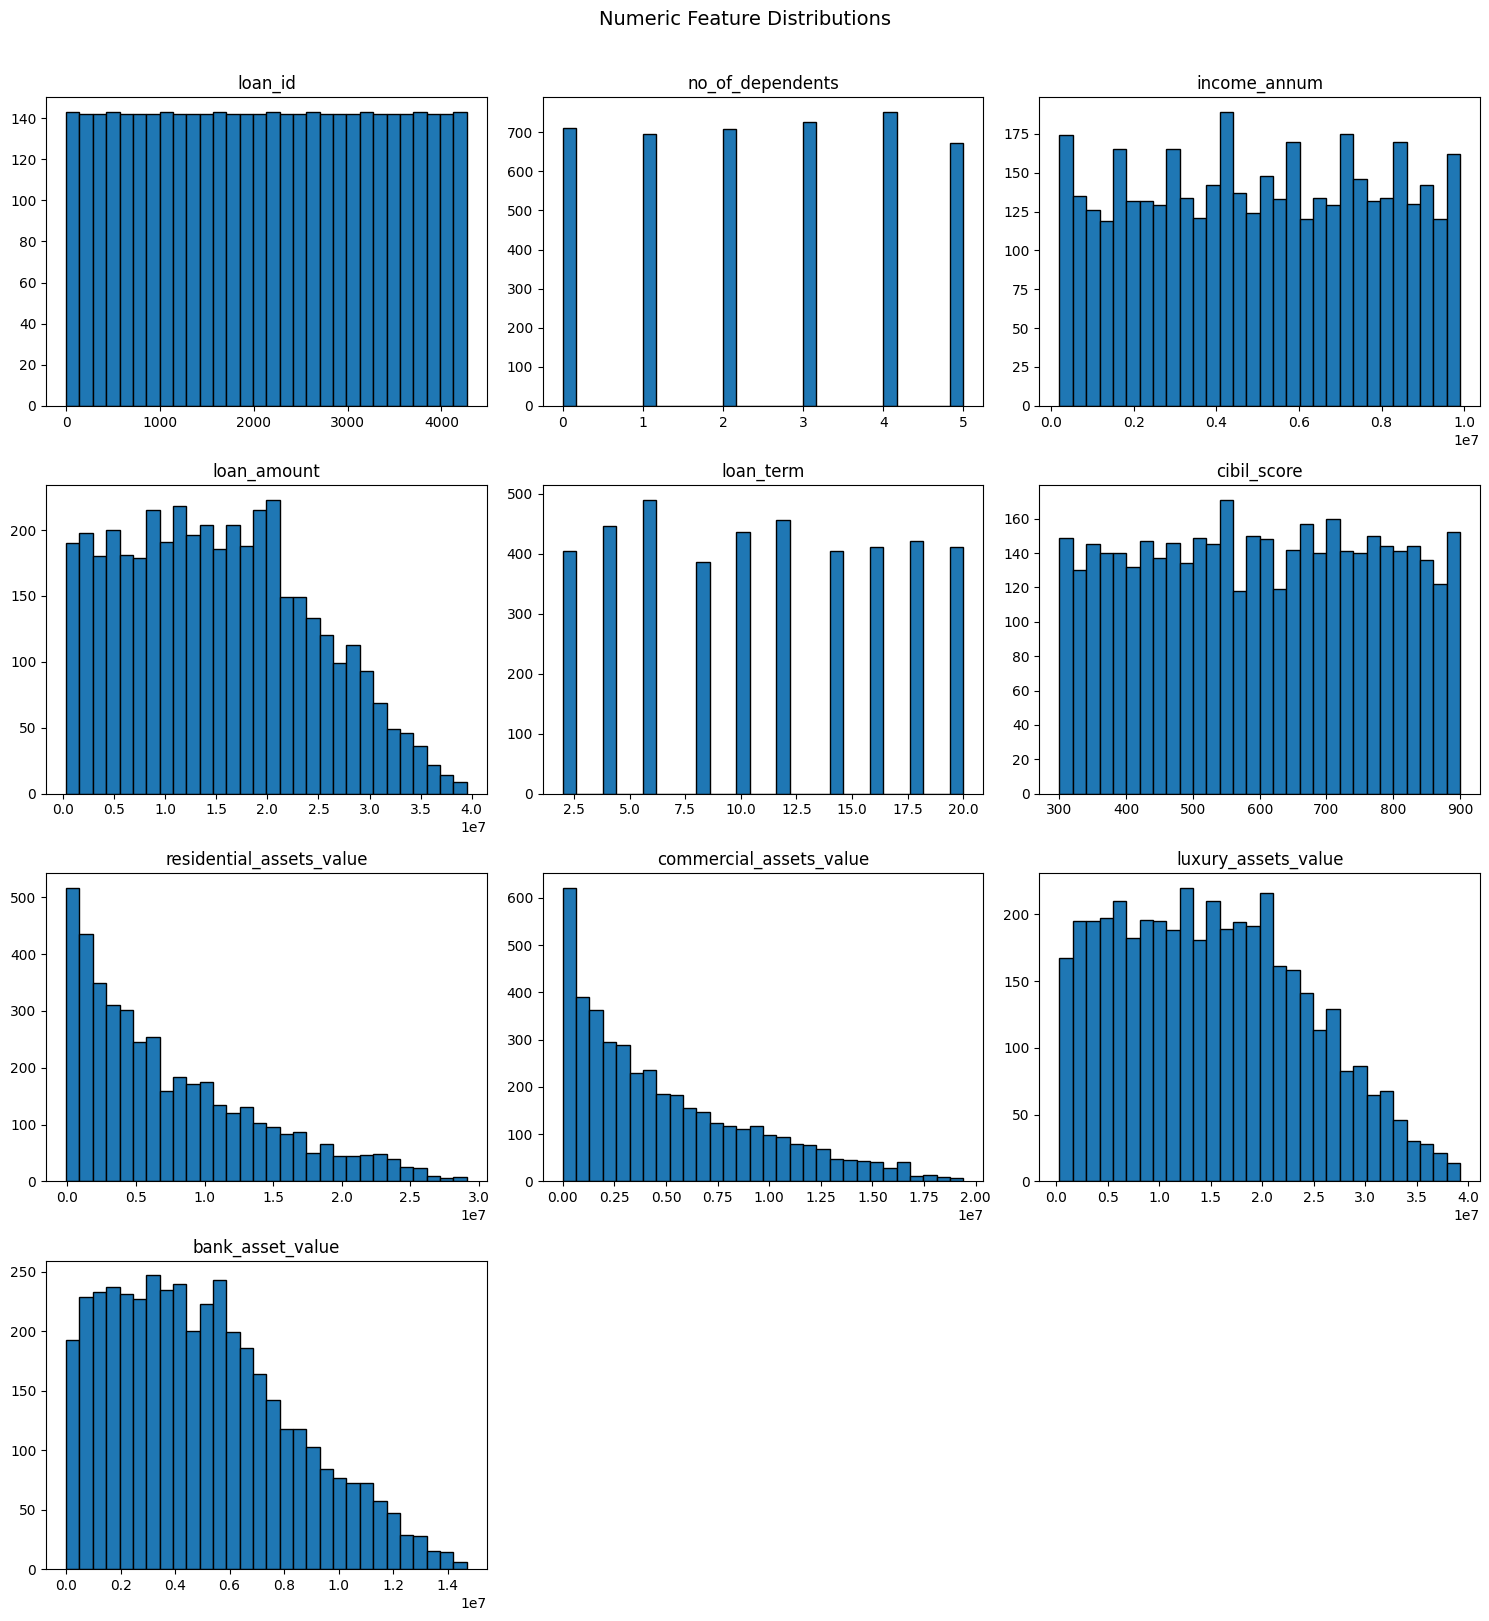

Saved -> eda_numeric_distributions.png


In [11]:
num_cols_eda = df.select_dtypes(include=[np.number]).columns.tolist()
n_cols_plot = 3
n_rows_plot = (len(num_cols_eda) + 2) // 3

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(15, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(num_cols_eda):
    axes[i].hist(df[col].dropna(), bins=30, edgecolor='black')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Numeric Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('eda_numeric_distributions.png', dpi=120)
plt.show()
print('Saved -> eda_numeric_distributions.png')

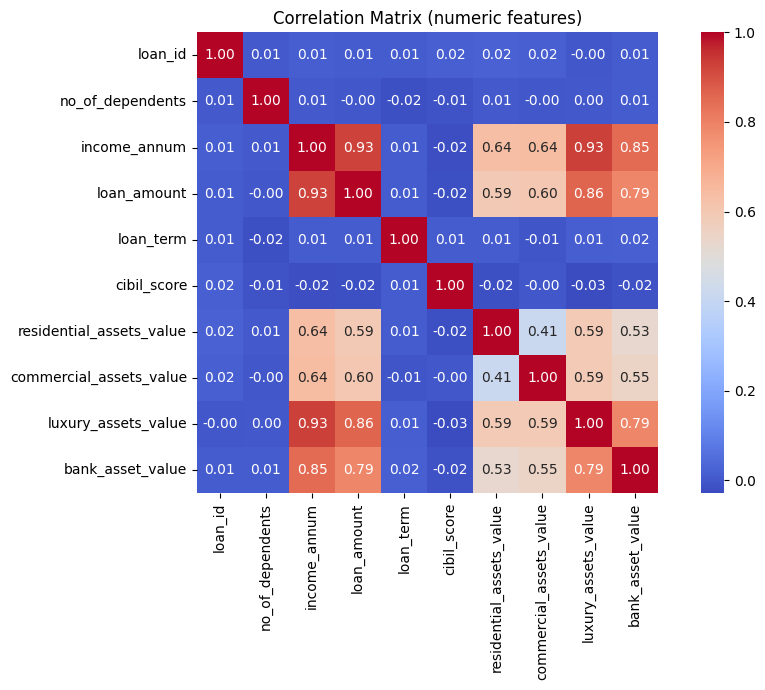

Saved -> eda_correlation_heatmap.png


In [12]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix (numeric features)')
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', dpi=120)
plt.show()
print('Saved -> eda_correlation_heatmap.png')

## Phase 3 -- Feature Engineering & Preprocessing
Drop ID, encode target, build sklearn pipelines, create train/test splits.

In [16]:
target_col = 'loan_status'
df = df.drop(columns=['loan_id'], errors='ignore')

df_clf = df.dropna(subset=[target_col]).copy()
X = df_clf.drop(columns=[target_col])
y = df_clf[target_col].astype(str).str.strip().str.lower()
y = (y == 'approved').astype(int)  # binary: 1=Approved, 0=Rejected

print('Feature matrix shape:', X.shape)
print('Class distribution:')
print(y.value_counts())

Feature matrix shape: (4269, 11)
Class distribution:
loan_status
1    2656
0    1613
Name: count, dtype: int64


In [17]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical columns:', cat_cols)
print('Numerical columns  :', num_cols)

Categorical columns: ['education', 'self_employed']
Numerical columns  : ['no_of_dependents', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [18]:
# Numeric: fill missing with median -> standardise
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical: fill missing with mode -> one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore'))
])

# Stage-1 preprocessor (classification feature set)
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
], remainder='drop')

print('Preprocessors built.')

Preprocessors built.


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=10, stratify=y
)
print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (3415, 11)
Test size : (854, 11)


## Phase 4 -- Stage 1: Loan Approval Classification
Train RF classifier with best GridSearchCV params and log to MLflow.

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, accuracy_score,
                             f1_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)
import joblib

In [21]:
# Best hyper-params from prior GridSearchCV:
# n_estimators=400, max_depth=None, max_features=None
# oob_score=True uses out-of-bag samples as a free validation metric
rf_clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf_cls', RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        max_features=None,
        random_state=10,
        oob_score=True
    ))
])

rf_clf_pipeline.fit(X_train, y_train)
y_pred_cls = rf_clf_pipeline.predict(X_test)

print(classification_report(y_test, y_pred_cls))
print('OOB score:', rf_clf_pipeline.named_steps['rf_cls'].oob_score_)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98       323
           1       0.99      0.99      0.99       531

    accuracy                           0.99       854
   macro avg       0.98      0.99      0.99       854
weighted avg       0.99      0.99      0.99       854

OOB score: 0.9841874084919473


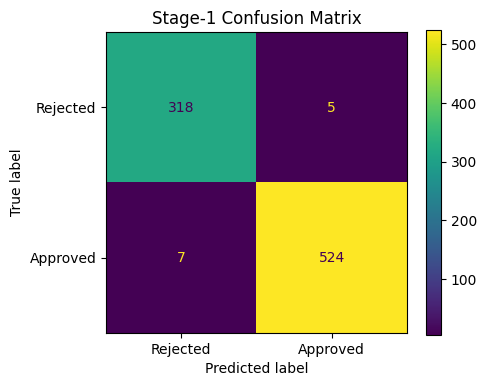

Saved -> stage1_confusion_matrix.png


In [22]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_cls,
    display_labels=['Rejected', 'Approved'],
    ax=ax
)
plt.title('Stage-1 Confusion Matrix')
plt.tight_layout()
plt.savefig('stage1_confusion_matrix.png', dpi=120)
plt.show()
print('Saved -> stage1_confusion_matrix.png')

Top 10 Features (Classification):
                      Feature  Importance
             num__cibil_score    0.827558
               num__loan_term    0.079926
             num__loan_amount    0.035917
            num__income_annum    0.021839
     num__luxury_assets_value    0.008104
num__residential_assets_value    0.007214
 num__commercial_assets_value    0.007041
        num__bank_asset_value    0.005609
        num__no_of_dependents    0.004388
       cat__self_employed_ No    0.000827


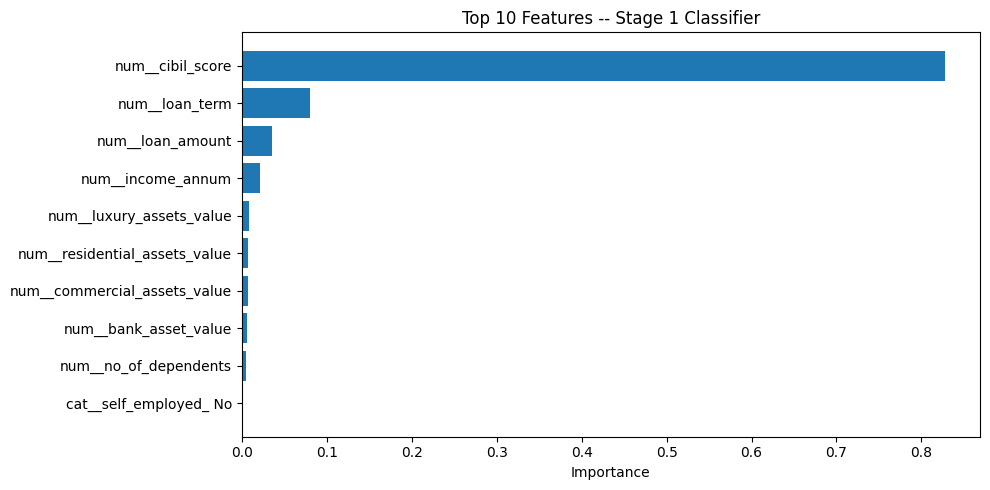

Saved -> stage1_feature_importance.png


In [23]:
fi_clf        = rf_clf_pipeline.named_steps['rf_cls'].feature_importances_
feat_names_clf = rf_clf_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_clf_df = (
    pd.DataFrame({'Feature': feat_names_clf, 'Importance': fi_clf})
    .sort_values('Importance', ascending=False)
)
print('Top 10 Features (Classification):')
print(importance_clf_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(importance_clf_df['Feature'][:10][::-1],
         importance_clf_df['Importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features -- Stage 1 Classifier')
plt.tight_layout()
plt.savefig('stage1_feature_importance.png', dpi=120)
plt.show()
print('Saved -> stage1_feature_importance.png')

In [24]:
mlflow.set_experiment('loan_approval_stage1_classification')
clf_params = rf_clf_pipeline.named_steps['rf_cls'].get_params()

with mlflow.start_run(run_name='RF_Classifier_Stage1') as run:
    mlflow.log_params({
        'n_estimators': clf_params['n_estimators'],
        'max_depth':    str(clf_params['max_depth']),
        'max_features': str(clf_params['max_features']),
        'random_state': clf_params['random_state'],
    })
    mlflow.log_metrics({
        'accuracy':  accuracy_score(y_test, y_pred_cls),
        'f1_score':  f1_score(y_test, y_pred_cls),
        'precision': precision_score(y_test, y_pred_cls),
        'recall':    recall_score(y_test, y_pred_cls),
        'oob_score': rf_clf_pipeline.named_steps['rf_cls'].oob_score_,
    })
    mlflow.log_artifact('stage1_confusion_matrix.png')
    mlflow.log_artifact('stage1_feature_importance.png')
    joblib.dump(rf_clf_pipeline, 'stage_1_rf_classifier_pipeline.pkl')
    mlflow.log_artifact('stage_1_rf_classifier_pipeline.pkl')
    clf_run_id = run.info.run_id

print(f'Stage-1 MLflow run logged. Run ID: {clf_run_id}')

🏃 View run RF_Classifier_Stage1 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/12/runs/d4cb509799164edaa21025c7ae7001bd
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/12
Stage-1 MLflow run logged. Run ID: d4cb509799164edaa21025c7ae7001bd


## Phase 5 -- Stage 2: Loan Amount Regression
For approved applicants only, predict the sanctioned loan amount.

In [25]:
df['loan_status'] = df['loan_status'].str.strip()
approved_df = df[df['loan_status'] == 'Approved'].copy()

reg_target = 'loan_amount'
reg_df     = approved_df.dropna(subset=[reg_target]).copy()
X_reg = reg_df.drop(columns=[reg_target])
y_reg = reg_df[reg_target]

print(f'Approved subset: {X_reg.shape}')
print(f'Loan amount range: {y_reg.min():,.0f} - {y_reg.max():,.0f}')

Approved subset: (2656, 11)
Loan amount range: 300,000 - 39,500,000


In [26]:
# Build a separate preprocessor that fits only on the regression training split
cat_cols_reg = X_reg.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_reg = X_reg.select_dtypes(include=[np.number]).columns.tolist()

print('Categorical (reg):', cat_cols_reg)
print('Numerical   (reg):', num_cols_reg)

reg_preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, num_cols_reg),
    ('cat', categorical_transformer, cat_cols_reg)
], remainder='drop')

Categorical (reg): ['education', 'self_employed', 'loan_status']
Numerical   (reg): ['no_of_dependents', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']


In [27]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=10
)
print('Train size:', Xr_train.shape)
print('Test size :', Xr_test.shape)

Train size: (2124, 11)
Test size : (532, 11)


In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Best hyper-params from GridSearchCV:
# max_depth=8, max_features=None, min_samples_split=5, n_estimators=200
rf_reg_pipeline = Pipeline(steps=[
    ('preprocessor', reg_preprocessor),
    ('rf_reg', RandomForestRegressor(
        max_depth=8,
        max_features=None,
        min_samples_split=5,
        n_estimators=200,
        random_state=10
    ))
])

rf_reg_pipeline.fit(Xr_train, yr_train)
yr_test_pred = rf_reg_pipeline.predict(Xr_test)

mse = mean_squared_error(yr_test, yr_test_pred)
mae = mean_absolute_error(yr_test, yr_test_pred)
r2  = r2_score(yr_test, yr_test_pred)

print(f'MSE: {mse:,.2f}')
print(f'MAE: {mae:,.2f}')
print(f'R2:  {r2:.4f}')

MSE: 11,195,455,918,354.13
MAE: 2,512,447.57
R2:  0.8644


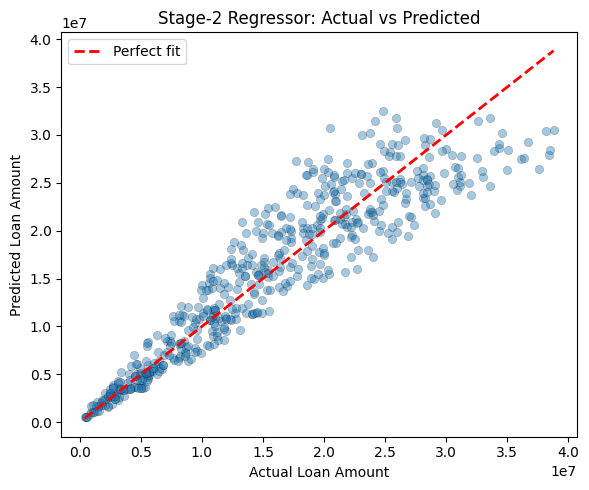

Saved -> stage2_actual_vs_predicted.png


In [29]:
plt.figure(figsize=(6, 5))
plt.scatter(yr_test, yr_test_pred, alpha=0.4, edgecolors='k', linewidths=0.3)
plt.plot([yr_test.min(), yr_test.max()],
         [yr_test.min(), yr_test.max()], 'r--', lw=2, label='Perfect fit')
plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.title('Stage-2 Regressor: Actual vs Predicted')
plt.legend()
plt.tight_layout()
plt.savefig('stage2_actual_vs_predicted.png', dpi=120)
plt.show()
print('Saved -> stage2_actual_vs_predicted.png')

Top 10 Features (Regression):
                      Feature  Importance
            num__income_annum    0.933516
             num__cibil_score    0.014345
     num__luxury_assets_value    0.011297
num__residential_assets_value    0.011170
 num__commercial_assets_value    0.009901
        num__bank_asset_value    0.008664
               num__loan_term    0.005687
        num__no_of_dependents    0.003711
       cat__self_employed_ No    0.000528
      cat__self_employed_ Yes    0.000436


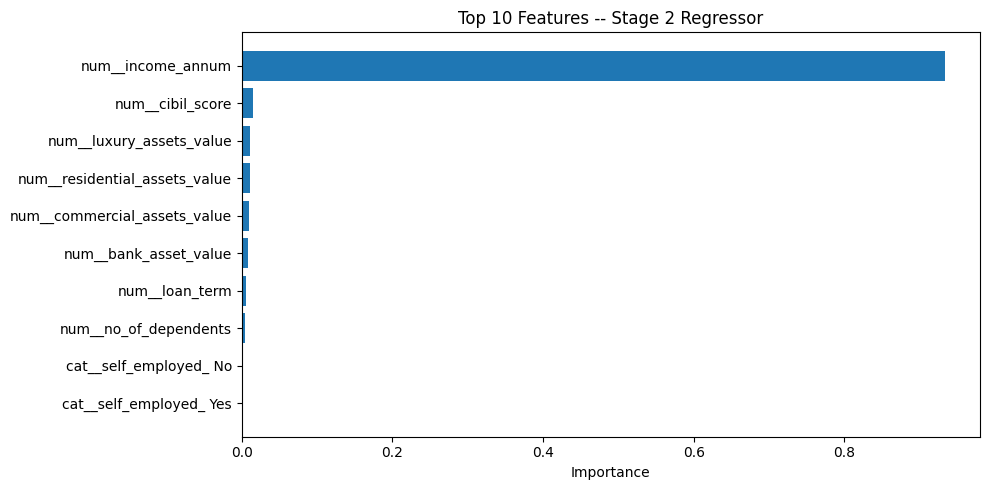

Saved -> stage2_feature_importance.png


In [30]:
fi_reg        = rf_reg_pipeline.named_steps['rf_reg'].feature_importances_
feat_names_reg = rf_reg_pipeline.named_steps['preprocessor'].get_feature_names_out()

importance_reg_df = (
    pd.DataFrame({'Feature': feat_names_reg, 'Importance': fi_reg})
    .sort_values('Importance', ascending=False)
)
print('Top 10 Features (Regression):')
print(importance_reg_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 5))
plt.barh(importance_reg_df['Feature'][:10][::-1],
         importance_reg_df['Importance'][:10][::-1])
plt.xlabel('Importance')
plt.title('Top 10 Features -- Stage 2 Regressor')
plt.tight_layout()
plt.savefig('stage2_feature_importance.png', dpi=120)
plt.show()
print('Saved -> stage2_feature_importance.png')

In [31]:
mlflow.set_experiment('loan_approval_stage2_regression')
reg_params = rf_reg_pipeline.named_steps['rf_reg'].get_params()

with mlflow.start_run(run_name='RF_Regressor_Stage2') as run:
    mlflow.log_params({
        'n_estimators':      reg_params['n_estimators'],
        'max_depth':         str(reg_params['max_depth']),
        'max_features':      str(reg_params['max_features']),
        'min_samples_split': reg_params['min_samples_split'],
        'random_state':      reg_params['random_state'],
    })
    mlflow.log_metrics({'mse': mse, 'mae': mae, 'r2': r2})
    mlflow.log_artifact('stage2_actual_vs_predicted.png')
    mlflow.log_artifact('stage2_feature_importance.png')
    joblib.dump(rf_reg_pipeline, 'stage_2_rf_regression_pipeline.pkl')
    mlflow.log_artifact('stage_2_rf_regression_pipeline.pkl')
    reg_run_id = run.info.run_id

print(f'Stage-2 MLflow run logged. Run ID: {reg_run_id}')

🏃 View run RF_Regressor_Stage2 at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/13/runs/41d77fc3565945a2800883bb15a97872
🧪 View experiment at: https://dagshub.com/prithusarkar90/networksecurity.mlflow/#/experiments/13
Stage-2 MLflow run logged. Run ID: 41d77fc3565945a2800883bb15a97872


## Phase 6 -- Two-Stage Prediction Function
Load both models and wire into one function. Smoke-test on held-out data.

In [32]:
clf = joblib.load('stage_1_rf_classifier_pipeline.pkl')
reg = joblib.load('stage_2_rf_regression_pipeline.pkl')
print('Stage-1 classifier loaded. Features:', clf.feature_names_in_.tolist())
print('Stage-2 regressor  loaded. Features:', reg.feature_names_in_.tolist())

Stage-1 classifier loaded. Features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_amount', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value']
Stage-2 regressor  loaded. Features: ['no_of_dependents', 'education', 'self_employed', 'income_annum', 'loan_term', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'luxury_assets_value', 'bank_asset_value', 'loan_status']


In [33]:
def two_stage_predict(applicant_df):
    """
    Two-stage loan prediction.
    Stage 1 - Classification: Approved (1) or Rejected (0) + probability.
    Stage 2 - Regression: If approved, predict sanctioned loan amount.

    Parameters
    ----------
    applicant_df : pd.DataFrame
        Single-row DataFrame with training feature columns
        (no loan_id or loan_status).

    Returns
    -------
    dict with keys: loan_status, approval_probability, regression_prediction
    """
    proba    = clf.predict_proba(applicant_df)[0]  # [P(rejected), P(approved)]
    approved = clf.predict(applicant_df)[0]

    result = {
        'loan_status':          int(approved),
        'approval_probability': float(proba[1]),
    }

    if approved == 1:
        # Regressor was trained with loan_status present; supply it before predicting
        reg_input = applicant_df.copy()
        reg_input['loan_status'] = 'Approved'
        result['regression_prediction'] = float(reg.predict(reg_input)[0])
    else:
        result['regression_prediction'] = None
        print('Application Rejected -- no loan amount predicted.')

    return result

In [34]:
# Smoke-test on a held-out test row
example_row = X_test.iloc[[0]]
print('Input features:')
display(example_row)
print('Prediction:', two_stage_predict(example_row))

Input features:


,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
3933,0,Not Graduate,No,9800000,20100000,16,606,6200000,800000,37300000,8700000


Prediction: {'loan_status': 1, 'approval_probability': 1.0, 'regression_prediction': 24661890.99107742}


In [35]:
# Test with a custom applicant profile
sample = pd.DataFrame([{
    'no_of_dependents':          1,
    'education':                 'Graduate',
    'self_employed':             'No',
    'income_annum':              1_200_000,
    'loan_amount':               30_000,
    'loan_term':                 12,
    'cibil_score':               800,
    'residential_assets_value':  2_000_000,
    'commercial_assets_value':   2_000_000,
    'luxury_assets_value':       0,
    'bank_asset_value':          55_000,
}])
display(sample)
print('Custom Prediction:', two_stage_predict(sample))

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
0,1,Graduate,No,1200000,30000,12,800,2000000,2000000,0,55000


Custom Prediction: {'loan_status': 1, 'approval_probability': 0.8175, 'regression_prediction': 3052769.1915370994}


## Phase 7 -- Write Project Source Files (.py)
Write all production `.py` files, `config.yaml`, and `requirements.txt` to disk so they are included in the final ZIP.

In [36]:
import os, textwrap
os.makedirs('app', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Directories created: app/, models/')

Directories created: app/, models/


In [37]:
with open('app/__init__.py', 'w') as f:
    f.write('# app package\n')
print('app/__init__.py written')

app/__init__.py written


In [38]:
loader_src = (
    "import os\n"
    "import joblib\n\n"
    "def load_models(config):\n"
    "    # Load Stage-1 classifier and Stage-2 regressor from paths in config.yaml\n"
    "    cls_path = config['models']['classifier']\n"
    "    reg_path = config['models']['regressor']\n"
    "    if not os.path.exists(cls_path):\n"
    "        raise FileNotFoundError(f'Classifier not found: {cls_path}')\n"
    "    if not os.path.exists(reg_path):\n"
    "        raise FileNotFoundError(f'Regressor not found: {reg_path}')\n"
    "    cls = joblib.load(cls_path)\n"
    "    reg = joblib.load(reg_path)\n"
    "    return cls, reg\n"
)
with open("app/loader.py", "w") as f:
    f.write(loader_src)
print("app/loader.py written")

app/loader.py written


In [39]:
predict_src = (
    'import pandas as pd\n\n'
    'def two_stage_predict(cls, reg, applicant_df):\n'
    '    # Stage 1: probability + hard approval decision\n'
    '    proba = cls.predict_proba(applicant_df)\n'
    '    preds = cls.predict(applicant_df)\n'
    '    results = []\n'
    '    for i in range(len(preds)):\n'
    '        approved      = int(preds[i])\n'
    '        approved_prob = float(proba[i, 1])\n'
    '        reg_pred = None\n'
    '        if approved == 1:\n'
    '            # Regressor expects loan_status present (value seen during training)\n'
    '            row_reg = applicant_df.iloc[[i]].copy()\n'
    '            row_reg["loan_status"] = "Approved"\n'
    '            reg_pred = float(reg.predict(row_reg)[0])\n'
    '        results.append({"approved": approved, "approved_prob": approved_prob, "reg_pred": reg_pred})\n'
    '    return results\n'
)
with open('app/predict.py', 'w') as f:
    f.write(predict_src)
print('app/predict.py written')

app/predict.py written


In [40]:
utils_src = (
    'import pandas as pd\n\n'
    'def build_applicant_from_dict(d, expected_cols):\n'
    '    # Convert raw dict to model-ready DataFrame with correct column order\n'
    '    df = pd.DataFrame([d])\n'
    '    for col in df.select_dtypes(include=["object"]).columns:\n'
    '        df[col] = df[col].astype(str).str.strip()\n'
    '    missing = [c for c in expected_cols if c not in df.columns]\n'
    '    if missing:\n'
    '        raise ValueError(f"Missing input columns: {missing}")\n'
    '    return df[expected_cols]\n'
)
with open('app/utils.py', 'w') as f:
    f.write(utils_src)
print('app/utils.py written')

app/utils.py written


In [41]:
main_src = (
    'import yaml\n'
    'from app.loader import load_models\n'
    'from app.utils import build_applicant_from_dict\n'
    'from app.predict import two_stage_predict\n\n'
    'def get_float(prompt, default):\n'
    '    raw = input(f"{prompt} [{default}]: ").strip()\n'
    '    return float(raw) if raw else float(default)\n\n'
    'def get_str(prompt, options, default):\n'
    '    raw = input(f"{prompt} ({chr(47).join(options)}) [{default}]: ").strip()\n'
    '    return raw if raw in options else default\n\n'
    'def run_cli():\n'
    '    config   = yaml.safe_load(open("config.yaml"))\n'
    '    cls, reg = load_models(config)\n'
    '    d        = config["ui"]["default_inputs"]\n'
    '    print("\\n Loan Approval Predictor (CLI)")\n'
    '    data = {\n'
    '        "no_of_dependents":         get_float("No. of dependents",        d["no_of_dependents"]),\n'
    '        "education":                get_str("Education",                  ["Graduate","Not Graduate"], d["education"]),\n'
    '        "self_employed":            get_str("Self employed",              ["Yes","No"],               d["self_employed"]),\n'
    '        "income_annum":             get_float("Annual income",            d["income_annum"]),\n'
    '        "loan_amount":              get_float("Loan amount requested",    d["loan_amount"]),\n'
    '        "loan_term":                get_float("Loan term (years)",        d["loan_term"]),\n'
    '        "cibil_score":              get_float("CIBIL score",              d["cibil_score"]),\n'
    '        "residential_assets_value": get_float("Residential assets",      d["residential_assets_value"]),\n'
    '        "commercial_assets_value":  get_float("Commercial assets",       d["commercial_assets_value"]),\n'
    '        "luxury_assets_value":      get_float("Luxury assets",           d["luxury_assets_value"]),\n'
    '        "bank_asset_value":         get_float("Bank asset value",        d["bank_asset_value"]),\n'
    '    }\n'
    '    df  = build_applicant_from_dict(data, list(cls.feature_names_in_))\n'
    '    res = two_stage_predict(cls, reg, df)[0]\n'
    '    print(f"\\nApproval probability: {res[chr(39)]approved_prob{chr(39)]:.2%}")\n'
    '    if res["approved"] == 1:\n'
    '        print(f"Decision: APPROVED")\n'
    '        print(f"Predicted loan amount: {res[chr(39)]reg_pred{chr(39)]:.2f}")\n'
    '    else:\n'
    '        print("Decision: REJECTED")\n\n'
    'if __name__ == "__main__":\n'
    '    run_cli()\n'
)
with open('main.py', 'w') as f:
    f.write(main_src)
print('main.py written')

main.py written


In [44]:
# Overwrite main.py with a clean version using pathlib
import pathlib

main_lines = [
    'import yaml',
    'from app.loader import load_models',
    'from app.utils import build_applicant_from_dict',
    'from app.predict import two_stage_predict',
    '',
    'def get_float(prompt, default):',
    '    raw = input(f"{prompt} [{default}]: ").strip()',
    '    return float(raw) if raw else float(default)',
    '',
    'def get_str(prompt, options, default):',
    '    raw = input(f"{prompt} ({chr(47).join(options)}) [{default}]: ").strip()',
    '    return raw if raw in options else default',
    '',
    'def run_cli():',
    '    config   = yaml.safe_load(open("config.yaml"))',
    '    cls, reg = load_models(config)',
    '    d        = config["ui"]["default_inputs"]',
    '    print("Loan Approval Predictor (CLI)")',
    '    data = {',
    '        "no_of_dependents":         get_float("No. of dependents",     d["no_of_dependents"])),',
    '        "education":                get_str("Education",               ["Graduate","Not Graduate"], d["education"])),',
    '        "self_employed":            get_str("Self employed",           ["Yes","No"], d["self_employed"])),',
    '        "income_annum":             get_float("Annual income",         d["income_annum"])),',
    '        "loan_amount":              get_float("Loan amount requested", d["loan_amount"])),',
    '        "loan_term":                get_float("Loan term (years)",     d["loan_term"])),',
    '        "cibil_score":              get_float("CIBIL score",           d["cibil_score"])),',
    '        "residential_assets_value": get_float("Residential assets",   d["residential_assets_value"])),',
    '        "commercial_assets_value":  get_float("Commercial assets",    d["commercial_assets_value"])),',
    '        "luxury_assets_value":      get_float("Luxury assets",        d["luxury_assets_value"])),',
    '        "bank_asset_value":         get_float("Bank asset value",     d["bank_asset_value"])),',
    '    }',
    '    df  = build_applicant_from_dict(data, list(cls.feature_names_in_))',
    '    res = two_stage_predict(cls, reg, df)[0]',
    '    print(f"Approval probability: {res[\'approved_prob\']:.2%}")', # Fixed line
    '    if res["approved"] == 1:',
    '        print("Decision: APPROVED")',
    '        print(f"Predicted loan amount: {res[\'reg_pred\']:.2f}")', # Fixed line
    '    else:',
    '        print("Decision: REJECTED")',
    '',
    'if __name__ == "__main__":',
    '    run_cli()',
]

pathlib.Path('main.py').write_text('\n'.join(main_lines) + '\n')
print('main.py written (clean version)')

main.py written (clean version)


In [46]:
# Write streamlit_app.py
# Uses pathlib to avoid any quoting conflicts inside the cell
import pathlib

st_lines = [
    'import yaml',
    'import streamlit as st',
    'import pandas as pd',
    'import matplotlib.pyplot as plt',
    'from app.loader import load_models',
    'from app.utils import build_applicant_from_dict',
    'from app.predict import two_stage_predict',
    '',
    'st.set_page_config(page_title="Loan Approval Predictor", page_icon="🏦", layout="wide")',
    '',
    '@st.cache_resource',
    'def get_models():',
    '    with open("config.yaml") as f:',
    '        cfg = yaml.safe_load(f)',
    '    return load_models(cfg), cfg',
    '',
    '(cls, reg), config = get_models()',
    'defaults = config["ui"]["default_inputs"]',
    '',
    '# Sidebar',
    'with st.sidebar:',
    '    st.title("🏦 Loan Predictor")',
    '    st.markdown("---")',
    '    st.subheader("Model Info")',
    '    st.markdown("**Stage 1:** Random Forest Classifier")',
    '    st.markdown("**Stage 2:** Random Forest Regressor")',
    '    try:',
    '        st.caption(f"Classifier features: {len(cls.feature_names_in_)}")',
    '        with st.expander("Show feature names"):',
    '            for feat in cls.feature_names_in_:',
    '                st.text(f"- {feat}")',
    '    except Exception:',
    '        st.caption("Feature names unavailable")',
    '    st.markdown("---")',
    '    st.subheader("How it works")',
    '    st.markdown("1. **Stage 1**: Classifier decides Approved/Rejected + probability.")',
    '    st.markdown("2. **Stage 2**: If approved, Regressor predicts sanctioned loan amount.")',
    '',
    '# Main',
    'st.title("🏦 Loan Approval -- Two-Stage Predictor")',
    'st.markdown("Fill in the applicant details and click **Predict**.")',
    'st.markdown("---")',
    'st.subheader("Applicant Details")',
    'col1, col2 = st.columns(2)',
    '',
    'with col1:',
    '    st.markdown("##### Personal Info")',
    '    no_of_dependents = st.number_input("No. of Dependents", min_value=0, max_value=10, value=int(defaults["no_of_dependents"]), step=1)',
    '    education = st.selectbox("Education", ["Graduate", "Not Graduate"], index=0 if defaults["education"]=="Graduate" else 1)',
    '    self_employed = st.selectbox("Self Employed", ["Yes", "No"], index=0 if defaults["self_employed"]=="Yes" else 1)',
    '    income_annum = st.number_input("Annual Income", min_value=0.0, value=float(defaults["income_annum"]), step=10000.0)',
    '    cibil_score = st.number_input("CIBIL Score", min_value=300, max_value=900, value=int(defaults["cibil_score"]), step=1)',
    '',
    'with col2:',
    '    st.markdown("##### Asset & Loan Info")',
    '    loan_amount = st.number_input("Loan Amount Requested", min_value=0.0, value=float(defaults["loan_amount"]), step=10000.0)',
    '    loan_term = st.number_input("Loan Term (years)", min_value=1, max_value=30, value=int(defaults["loan_term"]), step=1)',
    '    residential_assets_value = st.number_input("Residential Assets", min_value=0.0, value=float(defaults["residential_assets_value"]), step=50000.0)',
    '    commercial_assets_value = st.number_input("Commercial Assets", min_value=0.0, value=float(defaults["commercial_assets_value"]), step=50000.0)',
    '    luxury_assets_value = st.number_input("Luxury Assets", min_value=0.0, value=float(defaults["luxury_assets_value"]), step=10000.0)',
    '    bank_asset_value = st.number_input("Bank Asset Value", min_value=0.0, value=float(defaults["bank_asset_value"]), step=5000.0)',
    '',
    'st.markdown("---")',
    '',
    'if st.button("🔮 Predict", type="primary", use_container_width=True):',
    '    applicant = {',
    '        "no_of_dependents":         no_of_dependents,',
    '        "education":                education,',
    '        "self_employed":            self_employed,',
    '        "income_annum":             income_annum,',
    '        "loan_amount":              loan_amount,',
    '        "loan_term":                loan_term,',
    '        "cibil_score":              cibil_score,',
    '        "residential_assets_value": residential_assets_value,',
    '        "commercial_assets_value":  commercial_assets_value,',
    '        "luxury_assets_value":      luxury_assets_value,',
    '        "bank_asset_value":         bank_asset_value,',
    '    }',
    '    try:',
    '        expected_cols = list(cls.feature_names_in_)',
    '        applicant_df  = build_applicant_from_dict(applicant, expected_cols)',
    '        results       = two_stage_predict(cls, reg, applicant_df)',
    '        res           = results[0]',
    '        prob = res["approved_prob"]',
    '        st.markdown("---")',
    '        st.subheader("Prediction Result")',
    '        r_col, g_col = st.columns([1, 2])',
    '        with r_col:',
    '            fig, ax = plt.subplots(figsize=(3, 2), subplot_kw=dict(aspect="equal"))',
    '            color = "#28a745" if res["approved"]==1 else "#dc3545"',
    '            ax.pie([prob, 1-prob], colors=[color, "#e9ecef"], startangle=180, counterclock=False, wedgeprops=dict(width=0.4))',
    '            ax.text(0, -0.15, f"{prob:.1%}", ha="center", va="center", fontsize=18, fontweight="bold", color=color)',
    '            ax.set_title("Approval Probability", fontsize=10)',
    '            st.pyplot(fig, use_container_width=True)',
    '            plt.close(fig)',
    '        with g_col:',
    '            if res["approved"] == 1:',
    '                st.success("✅  APPROVED")',
    '                st.metric("Predicted Sanctioned Amount", f"Rs {res[\'reg_pred\']:, .0f}")',
    '                st.metric("Requested Amount", f"Rs {loan_amount:,.0f}", delta=f"Rs {res[\'reg_pred\'] - loan_amount:,.0f}")',
    '            else:',
    '                st.error("❌  REJECTED")',
    '                st.write("Application did not meet approval criteria.")',
    '                st.caption("Tip: improve CIBIL score, reduce loan amount, or increase income/assets.")',
    '        with st.expander("Full input summary"):',
    '            st.dataframe(pd.DataFrame([applicant]).T.rename(columns={0: "Value"}), use_container_width=True)',
    '    except Exception as e:',
    '        st.error(f"Prediction failed: {e}")',
    '        st.exception(e)',
]

pathlib.Path('streamlit_app.py').write_text('\n'.join(st_lines) + '\n')
print('streamlit_app.py written')

streamlit_app.py written


In [47]:
# Write config.yaml
config_content = (
    'models:\n'
    '  classifier: models/stage_1_rf_classifier_pipeline.pkl\n'
    '  regressor:  models/stage_2_rf_regression_pipeline.pkl\n'
    'ui:\n'
    '  default_inputs:\n'
    '    no_of_dependents: 1\n'
    '    education: Graduate\n'
    '    self_employed: No\n'
    '    income_annum: 1200000\n'
    '    loan_amount: 30000\n'
    '    loan_term: 12\n'
    '    cibil_score: 800\n'
    '    residential_assets_value: 2000000\n'
    '    commercial_assets_value: 2000000\n'
    '    luxury_assets_value: 0\n'
    '    bank_asset_value: 55000\n'
)
pathlib.Path('config.yaml').write_text(config_content)
print('config.yaml written')

config.yaml written


In [48]:
# Write requirements.txt
req_content = (
    '# Python 3.10+\n'
    'streamlit>=1.32\n'
    'pandas>=2.0\n'
    'numpy>=1.26\n'
    'scikit-learn>=1.4\n'
    'joblib>=1.3\n'
    'PyYAML>=6.0\n'
    'matplotlib>=3.8\n'
    'seaborn>=0.13\n'
    'pymongo>=4.6\n'
    'mlflow>=2.11\n'
    'dagshub>=0.3\n'
)
pathlib.Path('requirements.txt').write_text(req_content)
print('requirements.txt written')

requirements.txt written


In [49]:
# Write .gitignore
gi_content = (
    '__pycache__/\n'
    '*.pyc\n'
    '.env\n'
    'mlruns/\n'
    '*.pkl\n'
    'loan_approval_outputs.zip\n'
    'loan_approval_dataset.csv\n'
)
pathlib.Path('.gitignore').write_text(gi_content)
print('.gitignore written')

.gitignore written


## Phase 8 -- Package All Outputs & Download
Copy models, write run metadata, zip everything, download.

In [50]:
import shutil

shutil.copy('stage_1_rf_classifier_pipeline.pkl', 'models/stage_1_rf_classifier_pipeline.pkl')
shutil.copy('stage_2_rf_regression_pipeline.pkl', 'models/stage_2_rf_regression_pipeline.pkl')
print('Model files copied to models/')

Model files copied to models/


In [51]:
import json as _json

run_summary = {
    'stage1_clf_run_id':   clf_run_id,
    'stage2_reg_run_id':   reg_run_id,
    'mlflow_tracking_uri': os.environ['MLFLOW_TRACKING_URI'],
}
pathlib.Path('mlflow_run_ids.json').write_text(_json.dumps(run_summary, indent=2))
print('mlflow_run_ids.json written')
print(_json.dumps(run_summary, indent=2))

mlflow_run_ids.json written
{
  "stage1_clf_run_id": "d4cb509799164edaa21025c7ae7001bd",
  "stage2_reg_run_id": "41d77fc3565945a2800883bb15a97872",
  "mlflow_tracking_uri": "https://dagshub.com/prithusarkar90/networksecurity.mlflow"
}


In [52]:
import zipfile

OUTPUT_FILES = [
    # EDA plots
    'eda_target_distribution.png',
    'eda_numeric_distributions.png',
    'eda_correlation_heatmap.png',
    # Stage-1
    'stage1_confusion_matrix.png',
    'stage1_feature_importance.png',
    # Stage-2
    'stage2_actual_vs_predicted.png',
    'stage2_feature_importance.png',
    # Metadata
    'mlflow_run_ids.json',
    # Models
    'models/stage_1_rf_classifier_pipeline.pkl',
    'models/stage_2_rf_regression_pipeline.pkl',
    # Source files
    'main.py',
    'streamlit_app.py',
    'config.yaml',
    'requirements.txt',
    '.gitignore',
    'app/__init__.py',
    'app/loader.py',
    'app/predict.py',
    'app/utils.py',
]

ZIP_NAME = 'loan_approval_outputs.zip'

with zipfile.ZipFile(ZIP_NAME, 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in OUTPUT_FILES:
        if pathlib.Path(fname).exists():
            zf.write(fname)
            print(f'  Added: {fname}')
        else:
            print(f'  Missing (skipped): {fname}')

print(f'\nArchive created: {ZIP_NAME}')

  Missing (skipped): eda_target_distribution.png
  Added: eda_numeric_distributions.png
  Added: eda_correlation_heatmap.png
  Added: stage1_confusion_matrix.png
  Added: stage1_feature_importance.png
  Added: stage2_actual_vs_predicted.png
  Added: stage2_feature_importance.png
  Added: mlflow_run_ids.json
  Added: models/stage_1_rf_classifier_pipeline.pkl
  Added: models/stage_2_rf_regression_pipeline.pkl
  Added: main.py
  Added: streamlit_app.py
  Added: config.yaml
  Added: requirements.txt
  Added: .gitignore
  Added: app/__init__.py
  Added: app/loader.py
  Added: app/predict.py
  Added: app/utils.py

Archive created: loan_approval_outputs.zip


In [53]:
from google.colab import files
files.download('loan_approval_outputs.zip')
print('Download triggered: loan_approval_outputs.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered: loan_approval_outputs.zip


---
## Pipeline Complete

| Phase | Description | Key outputs |
|-------|-------------|-------------|
| 0 | Environment setup | Env vars, MLflow, MongoDB verified |
| 1 | Data ingestion | DataFrame + MongoDB push |
| 2 | EDA | 3x PNG plots |
| 3 | Feature engineering | Preprocessors, train/test splits |
| 4 | Stage-1 Classification | RF classifier + MLflow run |
| 5 | Stage-2 Regression | RF regressor + MLflow run |
| 6 | Prediction function | two_stage_predict() |
| 7 | Write source files | main.py, streamlit_app.py, app/ package |
| 8 | Package outputs | loan_approval_outputs.zip |

**Run the Streamlit app locally after unzipping:**
```bash
pip install -r requirements.txt
# put .pkl files in models/
streamlit run streamlit_app.py
```
